# Generative AI - Assignment # 1
## Siddique Ahmad Ryan - 22i-0781 - Section: C

# Question 1


## Dataset Preparation

### Importing Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Model, Input
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from datasets import load_dataset

### Loading CIFAR-10 Dataset from hugging face

In [2]:
dataset = load_dataset('uoft-cs/cifar10')
train_data = dataset['train']
test_data = dataset['test']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

### Converting into numpy arrays

In [3]:
X_train = np.array([np.array(img) for img in train_data['img']])
y_train = np.array(train_data['label'])
X_test = np.array([np.array(img) for img in test_data['img']])
y_test = np.array(test_data['label'])

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000,)


### Data Preprocessing

#### Normalizing pixel values to $[0,1]$ range

In [4]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

#### One-hot encoding

In [5]:
num_classes = 10
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

#### Class names for CIFAR-10

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

#### Displaying sample images

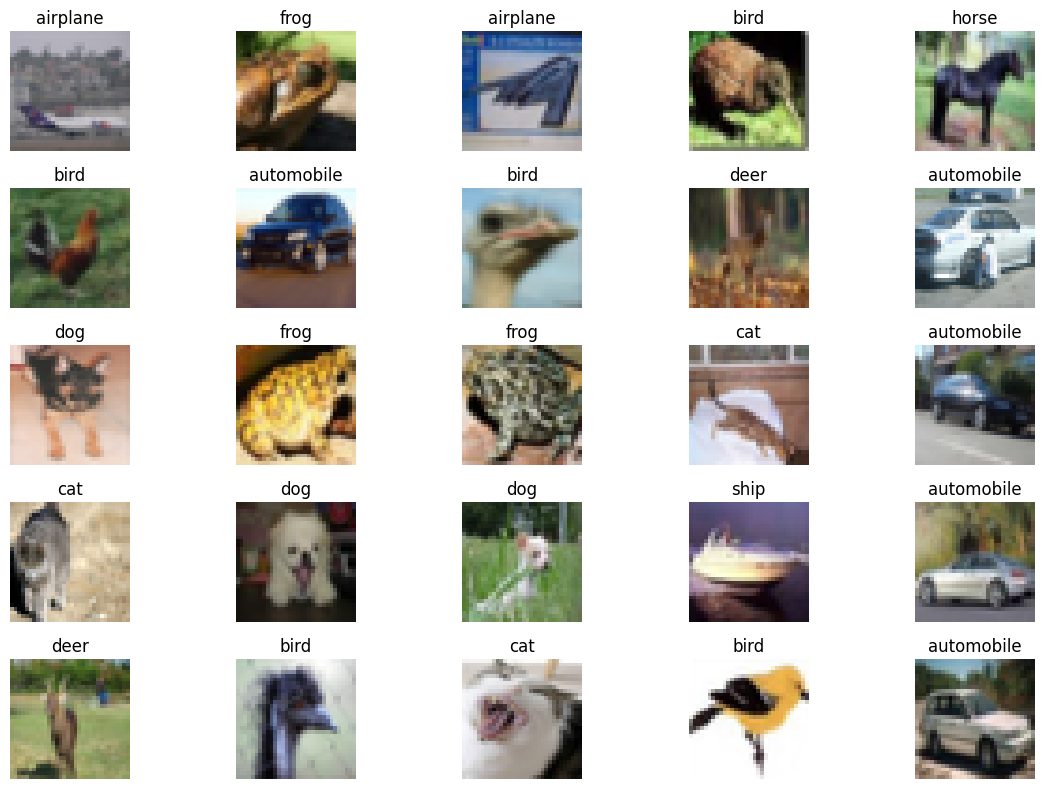

In [7]:
plt.figure(figsize=(12, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## CNN Model

### Architecture

In [8]:
def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    # Define the input tensor
    inputs = Input(shape=input_shape, name='input_layer')

    # First convolutional block
    x = layers.Conv2D(
        32, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(
        32, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Second convolutional block
    x = layers.Conv2D(
        64, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(
        64, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Third convolutional block
    x = layers.Conv2D(
        128, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(
        128, (3, 3), activation='relu',
        kernel_initializer='he_uniform', padding='same'
    )(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # Fully connected layers
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu', kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax', name='output_layer')(x)

    # Create the Model
    model = Model(inputs=inputs, outputs=outputs, name='cnn_functional')
    return model

# Create and compile the model
model = create_cnn_model()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "cnn_functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,344,170 (5.13 MB)

 Trainable params: 1,342,698 (5.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Model Training

### Configuration

In [9]:
batch_size = 32
epochs = 100
validation_split = 0.2


### Training

In [10]:
# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # can also use 'val_accuracy'
    patience=5,           # stop after 5 epochs with no improvement
    restore_best_weights=True # revert to best model weights
)

# Train with callback
history = model.fit(
    X_train, y_train_categorical,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    verbose=1,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.3272 - loss: 2.0718 - val_accuracy: 0.5606 - val_loss: 1.2688
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5774 - loss: 1.1874 - val_accuracy: 0.6714 - val_loss: 0.9273
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6477 - loss: 0.9996 - val_accuracy: 0.6539 - val_loss: 1.0318
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6955 - loss: 0.8771 - val_accuracy: 0.7050 - val_loss: 0.8399
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7224 - loss: 0.7890 - val_accuracy: 0.7644 - val_loss: 0.6812
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7511 - loss: 0.7102 - val_accuracy: 0.7599 - val_loss: 0.6975
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7668 - loss: 0.6805 - val_accuracy: 0.7945 - val_loss: 0.5975
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7837 - lo

### Ploting Training History

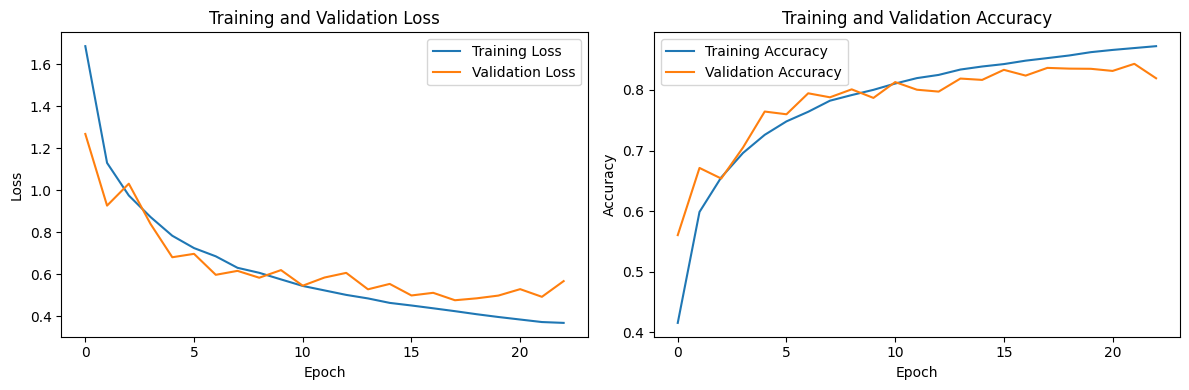

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation and Performance Metrics

### Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


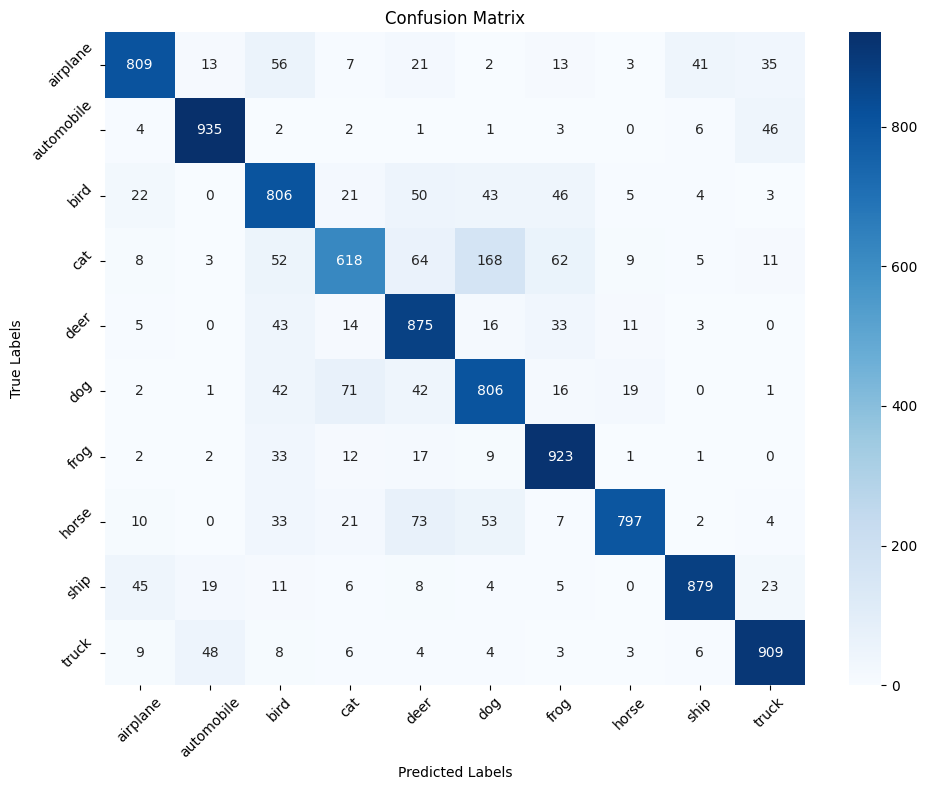

In [12]:
# Make predictions on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

### Classification Metrics

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

Accuracy: 0.8357
Precision: 0.8401
Recall: 0.8357
F1-Score: 0.8350

Detailed Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.81      0.84      1000
  automobile       0.92      0.94      0.93      1000
        bird       0.74      0.81      0.77      1000
         cat       0.79      0.62      0.70      1000
        deer       0.76      0.88      0.81      1000
         dog       0.73      0.81      0.77      1000
        frog       0.83      0.92      0.87      1000
       horse       0.94      0.80      0.86      1000
        ship       0.93      0.88      0.90      1000
       truck       0.88      0.91      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.83     10000
weighted avg       0.84      0.84      0.83     10000



## Feature Map Visualization

### Extracting the features

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

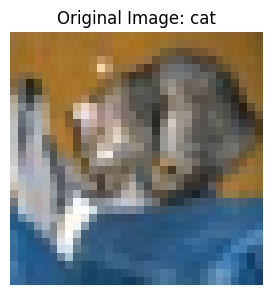

In [14]:
_ = model.predict(X_train[:1])

# Create a model for feature extraction
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in model.layers if 'conv2d' in layer.name]
)

# Select a sample image for visualization
sample_idx = 0
sample_image = X_test[sample_idx:sample_idx+1]
sample_label = class_names[y_test[sample_idx]]

# Extract feature maps
feature_maps = feature_extractor.predict(sample_image)

# Visualize original image
plt.figure(figsize=(15, 10))
plt.subplot(2, 4, 1)
plt.imshow(X_test[sample_idx])
plt.title(f'Original Image: {sample_label}')
plt.axis('off')

### Visualizing

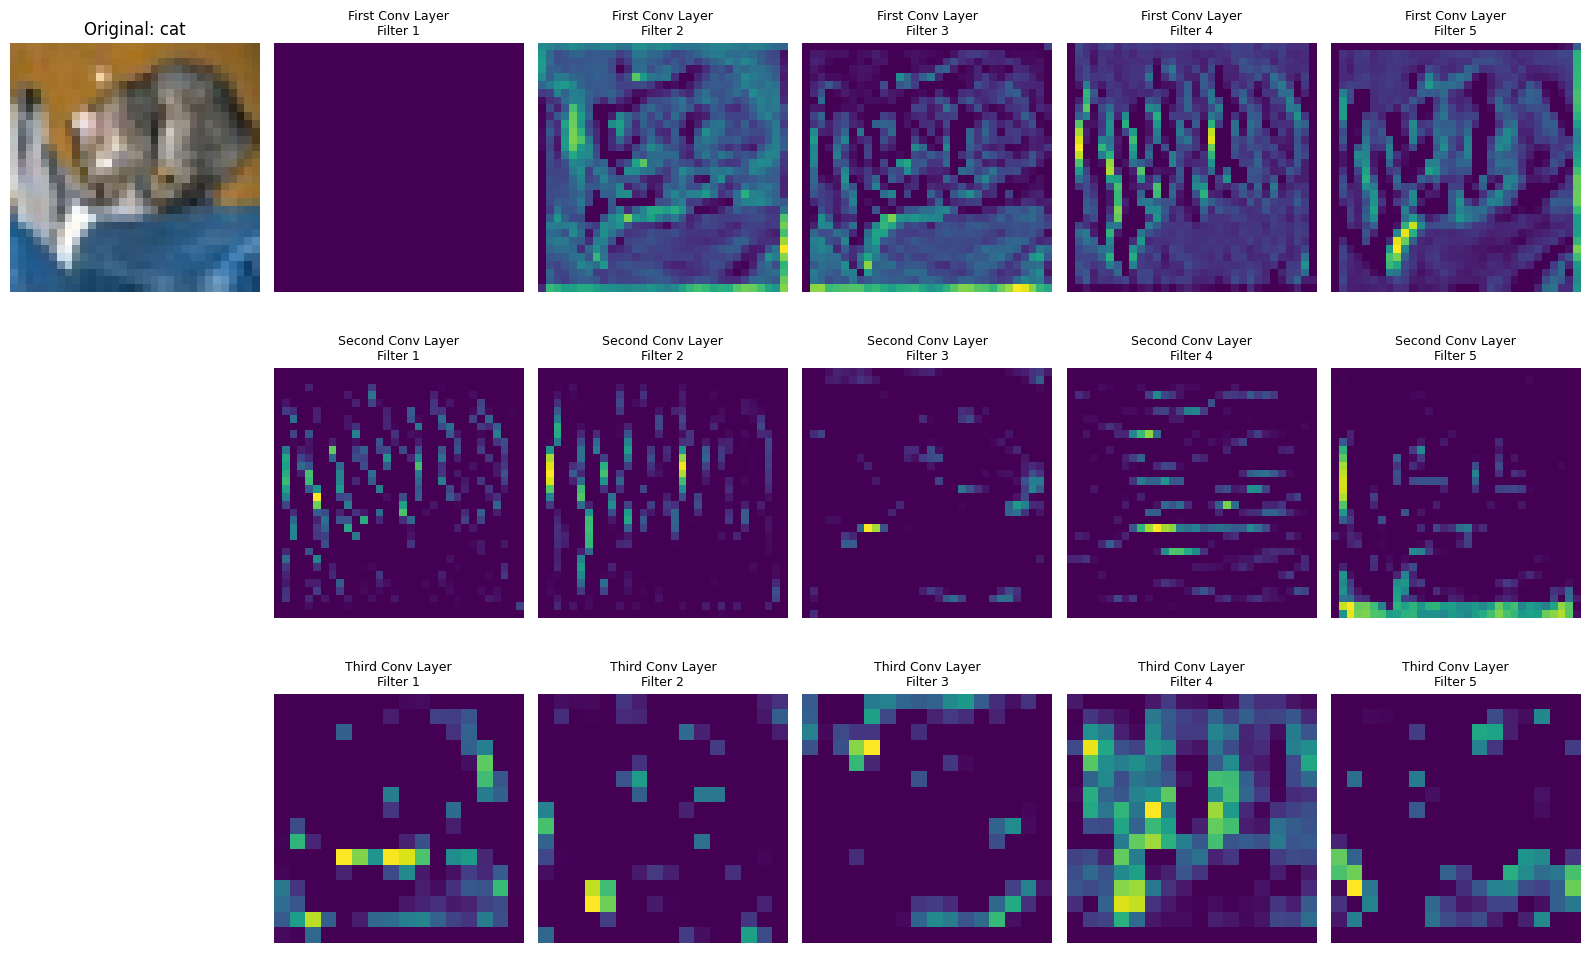

Analysis of Convolutional Layers:
1. First Layer: Detects low-level features like edges, corners, and basic shapes
2. Second Layer: Combines edge information to detect more complex patterns
3. Third Layer: Detects high-level features and object parts specific to classes


In [15]:
# Simpler visualization with better subplot management
plt.figure(figsize=(16, 10))

# Show original image
plt.subplot(3, 6, 1)
plt.imshow(X_test[sample_idx])
plt.title(f'Original: {sample_label}')
plt.axis('off')

# Show feature maps from first 3 conv layers (first 5 filters each)
layer_names = ['First Conv Layer', 'Second Conv Layer', 'Third Conv Layer']
plot_positions = [
    [2, 3, 4, 5, 6],      # First row positions for layer 1
    [8, 9, 10, 11, 12],   # Second row positions for layer 2
    [14, 15, 16, 17, 18]  # Third row positions for layer 3
]

for layer_idx, (feature_map, layer_name, positions) in enumerate(zip(feature_maps[:3], layer_names, plot_positions)):
    for filter_idx, pos in enumerate(positions):
        if filter_idx < feature_map.shape[-1]:
            plt.subplot(3, 6, pos)
            plt.imshow(feature_map[0, :, :, filter_idx], cmap='viridis')
            plt.title(f'{layer_name}\nFilter {filter_idx+1}', fontsize=9)
            plt.axis('off')

plt.tight_layout()
plt.show()

# Analysis
print("Analysis of Convolutional Layers:")
print("1. First Layer: Detects low-level features like edges, corners, and basic shapes")
print("2. Second Layer: Combines edge information to detect more complex patterns")
print("3. Third Layer: Detects high-level features and object parts specific to classes")


## Hyperparameter Ablation Study

### Hyperparameter Tuning Framework

In [ ]:
import itertools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def train_and_evaluate_model(learning_rate, batch_size, num_filters, num_layers):
    """Train and evaluate a model with given hyperparameters"""

    # Create model with specified parameters
    model = Sequential()

    # Add Input layer first to avoid warnings
    model.add(layers.Input(shape=(32, 32, 3)))

    # First layer
    model.add(layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Additional layers based on num_layers
    for i in range(num_layers - 1):
        filter_count = num_filters * (2 ** (i + 1))
        model.add(layers.Conv2D(filter_count, (3, 3), activation='relu', padding='same'))

        # Only add MaxPooling if we have enough spatial dimensions
        # CIFAR-10 is 32x32, so after 3 MaxPooling (2x2) operations: 32->16->8->4
        # After 4 MaxPooling operations: 32->16->8->4->2
        # After 5 MaxPooling operations: 32->16->8->4->2->1
        if i < 4:  # Limit MaxPooling to prevent dimensions going below 2x2
            model.add(layers.MaxPooling2D((2, 2)))

    # Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    # Compile with specified learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train model (reduced epochs for ablation study)
    try:
        history = model.fit(X_train, y_train_categorical,
                           batch_size=batch_size,
                           epochs=20,
                           validation_split=0.2,
                           verbose=0)

        # Evaluate on test set
        y_pred = model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)

        accuracy = accuracy_score(y_test, y_pred_classes)
        precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

        return accuracy, precision, recall, f1

    except Exception as e:
        print(f"Error training model: {e}")
        return 0.0, 0.0, 0.0, 0.0


# Hyperparameter ranges
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [16, 32, 64]
num_filters_options = [16, 32, 64]
num_layers_options = [3, 5, 7]

# Perform ablation study
results = []

# Test each hyperparameter individually (keeping others at baseline)
baseline = {'lr': 0.001, 'batch': 32, 'filters': 32, 'layers': 3}

print("Performing Hyperparameter Ablation Study...")

# Learning Rate ablation
print("\n1. Learning Rate Ablation:")
for lr in learning_rates:
    acc, prec, rec, f1 = train_and_evaluate_model(lr, baseline['batch'],
                                                  baseline['filters'], baseline['layers'])
    results.append(['Learning Rate', lr, acc, prec, rec, f1])
    print(f"LR: {lr}, Accuracy: {acc:.4f}")

# Batch Size ablation
print("\n2. Batch Size Ablation:")
for batch_size in batch_sizes:
    acc, prec, rec, f1 = train_and_evaluate_model(baseline['lr'], batch_size,
                                                  baseline['filters'], baseline['layers'])
    results.append(['Batch Size', batch_size, acc, prec, rec, f1])
    print(f"Batch: {batch_size}, Accuracy: {acc:.4f}")

# Number of Filters ablation
print("\n3. Number of Filters Ablation:")
for n_filters in num_filters_options:
    acc, prec, rec, f1 = train_and_evaluate_model(baseline['lr'], baseline['batch'],
                                                  n_filters, baseline['layers'])
    results.append(['Num Filters', n_filters, acc, prec, rec, f1])
    print(f"Filters: {n_filters}, Accuracy: {acc:.4f}")

# Number of Layers ablation
print("\n4. Number of Layers Ablation:")
for n_layers in num_layers_options:
    acc, prec, rec, f1 = train_and_evaluate_model(baseline['lr'], baseline['batch'],
                                                  baseline['filters'], n_layers)
    results.append(['Num Layers', n_layers, acc, prec, rec, f1])
    print(f"Layers: {n_layers}, Accuracy: {acc:.4f}")

# Create results DataFrame and display
import pandas as pd
results_df = pd.DataFrame(results, columns=['Hyperparameter', 'Value', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\nHyperparameter Tuning Results:")
print(results_df.to_string(index=False))

# Find optimal hyperparameters
optimal_results = results_df.loc[results_df.groupby('Hyperparameter')['Accuracy'].idxmax()]
print("\nOptimal Values for Each Hyperparameter:")
print(optimal_results[['Hyperparameter', 'Value', 'Accuracy']].to_string(index=False))

# Train final model with optimal hyperparameters
print("\nTraining final optimized model...")
optimal_lr = optimal_results[optimal_results['Hyperparameter'] == 'Learning Rate']['Value'].iloc[0]
optimal_batch = int(optimal_results[optimal_results['Hyperparameter'] == 'Batch Size']['Value'].iloc[0])
optimal_filters = int(optimal_results[optimal_results['Hyperparameter'] == 'Num Filters']['Value'].iloc[0])
optimal_layers = int(optimal_results[optimal_results['Hyperparameter'] == 'Num Layers']['Value'].iloc[0])

print(f"Optimal Configuration:")
print(f"Learning Rate: {optimal_lr}")
print(f"Batch Size: {optimal_batch}")
print(f"Number of Filters: {optimal_filters}")
print(f"Number of Layers: {optimal_layers}")

# Train final optimized model
final_acc, final_prec, final_rec, final_f1 = train_and_evaluate_model(
    optimal_lr, optimal_batch, optimal_filters, optimal_layers
)

# Get baseline performance (from your previously trained model)
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = train_and_evaluate_model(
    baseline['lr'], baseline['batch'], baseline['filters'], baseline['layers']
)

# Performance comparison table
performance_comparison = pd.DataFrame({
    'Model': ['Baseline CNN', 'Optimized CNN'],
    'Accuracy': [baseline_acc, final_acc],
    'Precision': [baseline_prec, final_prec],
    'Recall': [baseline_rec, final_rec],
    'F1-Score': [baseline_f1, final_f1]
})

print("\nPerformance Metrics Comparison:")
print(performance_comparison.to_string(index=False))


Performing Hyperparameter Ablation Study...

1. Learning Rate Ablation:
LR: 0.001, Accuracy: 0.7348
LR: 0.01, Accuracy: 0.1000
LR: 0.1, Accuracy: 0.1000

2. Batch Size Ablation:
Batch: 16, Accuracy: 0.7385
Batch: 32, Accuracy: 0.7442
Batch: 64, Accuracy: 0.7509

3. Number of Filters Ablation:
Filters: 16, Accuracy: 0.7279
Filters: 32, Accuracy: 0.7486
Filters: 64, Accuracy: 0.7509

4. Number of Layers Ablation:
Layers: 3, Accuracy: 0.7487
Layers: 5, Accuracy: 0.6950
Layers: 7, Accuracy: 0.6982

Hyperparameter Tuning Results:
Hyperparameter  Value  Accuracy  Precision  Recall  F1-Score
 Learning Rate  0.001    0.7348   0.737182  0.7348  0.735173
 Learning Rate  0.010    0.1000   0.010000  0.1000  0.018182
 Learning Rate  0.100    0.1000   0.010000  0.1000  0.018182
    Batch Size 16.000    0.7385   0.737802  0.7385  0.737732
    Batch Size 32.000    0.7442   0.748162  0.7442  0.744851
    Batch Size 64.000    0.7509   0.753487  0.7509  0.749826
   Num Filters 16.000    0.7279   0.728271

### Results Comparison Table

In [18]:
import pandas as pd

# Create results DataFrame
results_df = pd.DataFrame(results, columns=['Hyperparameter', 'Value', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Display results table
print("\nHyperparameter Tuning Results:")
print(results_df.to_string(index=False))

# Find optimal hyperparameters
optimal_results = results_df.loc[results_df.groupby('Hyperparameter')['Accuracy'].idxmax()]
print("\nOptimal Values for Each Hyperparameter:")
print(optimal_results[['Hyperparameter', 'Value', 'Accuracy']].to_string(index=False))

# Train final model with optimal hyperparameters
optimal_lr = optimal_results[optimal_results['Hyperparameter'] == 'Learning Rate']['Value'].iloc[0]
optimal_batch = int(optimal_results[optimal_results['Hyperparameter'] == 'Batch Size']['Value'].iloc[0])
optimal_filters = int(optimal_results[optimal_results['Hyperparameter'] == 'Num Filters']['Value'].iloc[0])
optimal_layers = int(optimal_results[optimal_results['Hyperparameter'] == 'Num Layers']['Value'].iloc[0])

print(f"\nOptimal Configuration:")
print(f"Learning Rate: {optimal_lr}")
print(f"Batch Size: {optimal_batch}")
print(f"Number of Filters: {optimal_filters}")
print(f"Number of Layers: {optimal_layers}")

# Train final optimized model
print("\nTraining final optimized model...")
final_acc, final_prec, final_rec, final_f1 = train_and_evaluate_model(
    optimal_lr, optimal_batch, optimal_filters, optimal_layers
)

# Performance comparison table
performance_comparison = pd.DataFrame({
    'Model': ['Baseline CNN', 'Optimized CNN'],
    'Accuracy': [accuracy, final_acc],  # accuracy from initial model
    'Precision': [precision, final_prec],
    'Recall': [recall, final_rec],
    'F1-Score': [f1, final_f1]
})

print("\nPerformance Metrics Comparison:")
print(performance_comparison.to_string(index=False))



Hyperparameter Tuning Results:
Hyperparameter  Value  Accuracy  Precision  Recall  F1-Score
 Learning Rate  0.001    0.7348   0.737182  0.7348  0.735173
 Learning Rate  0.010    0.1000   0.010000  0.1000  0.018182
 Learning Rate  0.100    0.1000   0.010000  0.1000  0.018182
    Batch Size 16.000    0.7385   0.737802  0.7385  0.737732
    Batch Size 32.000    0.7442   0.748162  0.7442  0.744851
    Batch Size 64.000    0.7509   0.753487  0.7509  0.749826
   Num Filters 16.000    0.7279   0.728271  0.7279  0.727158
   Num Filters 32.000    0.7486   0.748107  0.7486  0.746650
   Num Filters 64.000    0.7509   0.756860  0.7509  0.752290
    Num Layers  3.000    0.7487   0.750685  0.7487  0.748777
    Num Layers  5.000    0.6950   0.712360  0.6950  0.698765
    Num Layers  7.000    0.6982   0.705426  0.6982  0.699519

Optimal Values for Each Hyperparameter:
Hyperparameter  Value  Accuracy
    Batch Size 64.000    0.7509
 Learning Rate  0.001    0.7348
   Num Filters 64.000    0.7509
    Nu